In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [4]:
buurt_to_buurt = pl.read_csv('data/buurt_to_buurt.csv')


In [5]:
buurt_to_buurt.head()

buurt_ori_id,buurt_id,walk_2025_minutes,walk_2025_distance,walk_2025_detour_factor,bike_2025_smart_minutes,bike_2025_smart_distance,bike_2025_smart_detour_factor,ebike_2025_smart_minutes,ebike_2025_smart_distance,ebike_2025_smart_detour_factor,car_2025_minutes,car_2025_distance,car_2025_detour_factor,truck_2025_minutes,truck_2025_distance,truck_2025_detour_factor,ov_morning_minutes,ov_morning_distance,ov_morning_detour_factor,ov_midday_minutes,ov_midday_distance,ov_midday_detour_factor,ov_evening_minutes,ov_evening_distance,ov_evening_detour_factor,ov_weekend_morning_minutes,ov_weekend_morning_distance,ov_weekend_morning_detour_factor,bike_2040_smart_minutes,bike_2040_smart_distance,bike_2040_smart_detour_factor,bike_2040_utr_minutes,bike_2040_utr_distance,bike_2040_utr_detour_factor,ebike_2040_smart_minutes,ebike_2040_smart_distance,ebike_2040_smart_detour_factor
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BU08553202""","""BU19480113""",null,null,null,null,null,null,null,null,null,35.43,42286.24,1.19,40.58,42686.54,1.2,111.35,40079.88,1.13,108.1,40079.88,1.13,138.85,40493.2,1.14,141.22,40493.2,1.14,null,null,null,null,null,null,null,null,null
"""BU08553202""","""BU19480201""",null,null,null,97.19,28545.38,1.15,78.37,28643.36,1.15,26.46,30201.22,1.22,34.16,30653.38,1.23,89.09,28403.09,1.14,90.61,28403.09,1.14,86.54,28403.09,1.14,88.18,28403.09,1.14,97.96,28643.36,1.15,97.96,28643.36,1.15,78.37,28643.36,1.15
"""BU08553202""","""BU19480202""",null,null,null,97.38,28337.92,1.16,78.35,28402.03,1.16,26.82,29532.24,1.21,35.31,29984.4,1.23,86.67,27991.9,1.14,88.19,27991.9,1.14,84.13,27991.9,1.14,86.12,27991.9,1.14,97.92,28402.03,1.16,97.92,28402.03,1.16,78.35,28402.03,1.16
"""BU08553202""","""BU19480203""",null,null,null,93.06,27302.53,1.15,74.66,27379.7,1.16,27.44,27963.37,1.18,35.19,28415.54,1.2,92.79,26614.71,1.12,92.82,26614.71,1.12,107.85,26855.73,1.13,110.01,26855.73,1.13,93.31,27379.7,1.16,93.31,27379.7,1.16,74.66,27379.7,1.16
"""BU08553202""","""BU19480204""",null,null,null,null,null,null,84.97,31084.68,1.13,30.21,31858.38,1.16,34.47,32310.55,1.18,99.06,30362.86,1.11,95.45,30206.61,1.1,95.51,30670.31,1.12,97.88,30670.31,1.12,null,null,null,null,null,null,84.97,31084.68,1.13


In [2]:
buurt_2025 = pd.read_csv('data/buurt_2025.csv', sep = ';')
buurt_2025.head()

,Buurt2025,buurtnaam2025
0,00140000,Binnenstad-Noord
1,00140001,Binnenstad-Zuid
2,00140002,Binnenstad-Oost
3,00140003,Binnenstad-West
4,00140004,Noorderplantsoen


In [3]:
wijk = pd.read_csv('data/wijk_2025.csv', sep =';')
wijk.head()

,Wijk2025,wijknaam2025
0,001400,Centrum
1,001401,Oud-Zuid
2,001402,Oud-West
3,001403,Oud-Noord
4,001404,Oud-Oost


In [4]:
pc6hnr2025 = pd.read_csv('data/pc6hnr20250801_gwb.csv', sep=';')
pc6hnr2025.head()

C:\Users\daanr\AppData\Local\Temp\ipykernel_19220\2059166643.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  pc6hnr2025 = pd.read_csv('data/pc6hnr20250801_gwb.csv', sep=';')


,PC6,Huisnummer,Buurt2025,Wijk2025,Gemeente2025
0,1011AB,99,0363AF01,0363AF,363
1,1011AB,105,0363AF01,0363AF,363
2,1011AB,106,0363AF01,0363AF,363
3,1011AB,107,0363AF01,0363AF,363
4,1011AB,110,0363AF01,0363AF,363


In [5]:
voorzieningen = pd.read_csv('data/voorzieningen_per_buurt_klasse.csv')

voorzieningen.head()

,buurtcode,klasse_apotheek,klasse_basisschool,klasse_bushalte,klasse_fastfood,klasse_horeca,klasse_huisarts,klasse_kinderopvang,klasse_kledingwinkel,klasse_restaurant,klasse_sportterrein,klasse_supermarkt,klasse_treinstation,klasse_voortgezet_onderwijs,klasse_ziekenhuis,aantal_drinkwaterpunt
0,BU00140000,0,2+,1,2+,2+,1,1,2+,2+,0,2+,0,0,0,7
1,BU00140001,2+,0,2+,2+,2+,2+,2+,2+,2+,0,2+,0,2+,2+,0
2,BU00140002,0,2+,2+,2+,2+,1,1,1,2+,0,0,0,2+,0,0
3,BU00140003,0,0,2+,2+,2+,0,1,2+,2+,0,1,0,0,0,0
4,BU00140004,0,0,1,0,1,0,1,0,1,0,0,0,0,0,2


In [6]:
cbs = pd.read_excel('data/kwb2025.xlsx')
cbs.head()

,gwb_code_10,gwb_code_8,regio,gm_naam,recs,gwb_code,ind_wbi,a_inw,a_man,a_vrouw,...,g_afs_kv,g_afs_sc,g_3km_sc,a_opp_ha,a_lan_ha,a_wat_ha,pst_mvp,pst_dekp,ste_mvs,ste_oad
0,NL00,0000,Nederland,Nederland,Land,NL00,.,18044027,8978451,9065576,...,0.7,0.8,9.8,4154337,3364723,789614,.,.,2,2077
1,GM0014,0014,Groningen,Groningen,Gemeente,GM0014,1,244441,121379,123062,...,0.6,0.8,8.9,19796,18553,1244,.,.,1,3487
2,WK001400,001400,Centrum,Groningen,Wijk,WK001400,1,24980,12790,12185,...,0.5,0.8,14.1,241,228,13,.,.,1,6823
3,BU00140000,00140000,Binnenstad-Noord,Groningen,Buurt,BU00140000,1,4765,2495,2270,...,0.6,0.5,15.1,39,37,2,9712,1,1,7062
4,BU00140001,00140001,Binnenstad-Zuid,Groningen,Buurt,BU00140001,1,7085,3645,3440,...,0.5,0.9,13.3,59,55,4,9711,1,1,6765


In [2]:
odin_2024 = pl.read_excel('data/ODiN2024 Updated with Header/ODiN2024_DANS_Databestand_ Updated.xlsx').to_pandas()
odin_2024.head()

,OP,OPID,Mode,HHPers_DANS24,HHSam_DANS24,HHLft1_DANS24,HHLft2_DANS24,HHLft3_DANS24,HHLft4_DANS24,Wogem_DANS24,...,RAankUur,RAankMin,RReisduur,RReisduurBL,RTSamen,RCorrSnelh,RVliegVer,FactorH,FactorP,FactorV
0,1,350000661958,1,2,2,0,0,0,2,995,...,15.0,0.0,120.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
1,0,350000661958,1,2,2,0,0,0,2,995,...,17.0,0.0,60.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
2,0,350000661958,1,2,2,0,0,0,2,995,...,22.0,0.0,105.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
3,1,350000773958,1,2,2,0,0,0,2,1740,...,8.0,55.0,35.0,0.0,13.0,0.0,0.0,121.652967,243.305934,89049.971908
4,0,350000773958,1,2,2,0,0,0,2,1740,...,18.0,50.0,35.0,0.0,13.0,0.0,0.0,121.652967,243.305934,89049.971908


In [35]:
df = odin_2024.copy()
# AfstV is in hm, convert to km using /10
df['dist_km']      = df['AfstV'] / 10
# KHvm is bike usage
df['is_bike']      = df['KHvm'] == 5
df['is_car']       = df['Hvm'] == 1
df['is_walk']      = df['Hvm'] == 9
# add within 3 km bool
df['within3km']    = df['dist_km'] <= 3.0
# Same for within 10 minutes
df['within10min'] = df['Reisduur'] <= 10
# Essentials are (according to smartwayz): education, grocery shopping, services
df['is_essential'] = df['Doel'].isin([7, 8, 13])
# trip level weight we should always use this factor to get representative trip shares
df['wV'] = pd.to_numeric(df['FactorV'], errors='coerce').fillna(0)

#Keeping only regular trips
df = df[df['Verpl'] == 1].copy()

# Mode labels (from Hvm) for plots
mode_map = {1:'Car', 2:'Train', 3:'Bus', 4:'Tram', 5:'Metro',
            6:'Speedpedelec', 7:'E-bike', 8:'Bicycle', 9:'Walking',
            11:'Van', 16:'Motorcycle', 17:'Moped', 18:'Scooter', 14:'Taxi'}
df['mode_label'] = df['Hvm'].map(mode_map)

# Simplified modes to 6 groups for cleaner charts
simplify = {'Speedpedelec':'Cycling (all)', 'E-bike':'Cycling (all)', 'Bicycle':'Cycling (all)',
            'Tram':'Public transport', 'Metro':'Public transport', 'Bus':'Public transport',
            'Van':'Other', 'Motorcycle':'Other', 'Moped':'Other', 'Scooter':'Other', 'Taxi':'Other'}
df['mode_simple'] = df['mode_label'].replace(simplify)

# added provinces labels and city or not
sted_map = {1:'Very strongly urban', 2:'Strongly urban', 3:'Moderately urban',
            4:'Slightly urban', 5:'Not urban'}
prov_map = {1:'Groningen', 2:'Fryslân', 3:'Drenthe', 4:'Overijssel', 5:'Flevoland',
            6:'Gelderland', 7:'Utrecht', 8:'Noord-Holland', 9:'Zuid-Holland',
            10:'Zeeland', 11:'Noord-Brabant', 12:'Limburg'}
df['sted_label'] = df['Sted'].map(sted_map)
df['prov_label']  = df['Prov'].map(prov_map)

# HHGestInkG is standardised household income decile (1=lowest, 10 = highest)
df['income_group'] = pd.cut(df['HHGestInkG'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=['Low\n(1–2)', 'Low-mid\n(3–4)', 'Middle\n(5–6)',
            'High-mid\n(7–8)', 'High\n(9–10)'])

# plot theme, can change
sns.set_theme(style='whitegrid', font='sans-serif', font_scale=1.1)
COLORS = sns.color_palette('tab10')

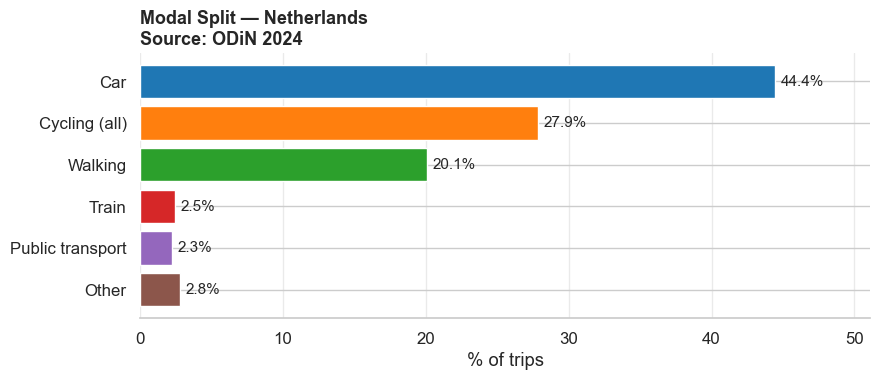

In [36]:
# Figure 1: Modal split: Overall travel mode distribution.

# Setting order for plot
order  = ['Car', 'Cycling (all)', 'Walking', 'Train', 'Public transport', 'Other']

# Weighting by weight factor
weighted = df.groupby('mode_simple')['wV'].sum()
shares = weighted / weighted.sum() * 100
shares = shares.reindex(order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(shares.index, shares.values, color=COLORS[:len(order)], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11)
ax.set_xlabel('% of trips')
ax.set_xlim(0, shares.max() * 1.15)
ax.invert_yaxis()
ax.set_title('Modal Split — Netherlands\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.grid(axis='x', alpha=0.4)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_modal_split.png', dpi=150)
plt.show()

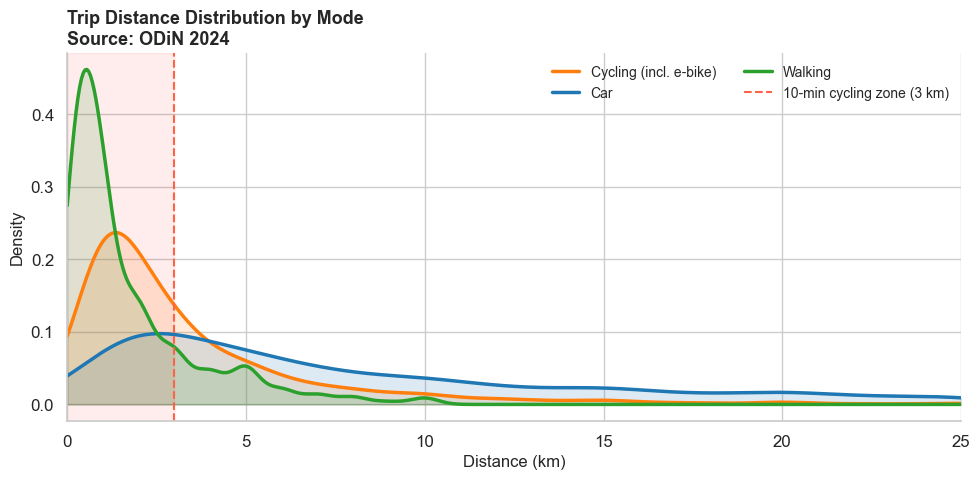

In [ ]:
# Figure 2: Trip distance distribution by mode of transport
fig, ax = plt.subplots(figsize=(10, 5))
# using KDE because a raw histogram is hard to compare across modes because of the different trip counts, kde normalizes
# Setting up distances to evaluate KDE over 0 to 25km smooth curve
x = np.linspace(0, 25, 500)

# car and cycling cap at 25km walking at 10. 
for mask, lbl, col in [
    (df['is_bike'] & (df['dist_km'] <= 25), 'Cycling (incl. e-bike)', COLORS[1]),
    (df['is_car']  & (df['dist_km'] <= 25), 'Car', COLORS[0]),
    (df['is_walk'] & (df['dist_km'] <= 10), 'Walking', COLORS[2]),
]:
    # Extracting distances and dropping rows which dont have distance
    vals = df.loc[mask, 'dist_km'].dropna().values
    # Fit kernel density estimator to the distance values ( creating guassian curve)
    kde  = gaussian_kde(vals, bw_method=0.2)
    ax.plot(x, kde(x), color=col, lw=2.5, label=lbl)
    ax.fill_between(x, kde(x), alpha=0.15, color=col)

ax.axvspan(0, 3.0,  alpha=0.07, color='red')
ax.axvline(3.0,  ls='--', color='tomato', lw=1.5, label='10-min cycling zone (3 km)')

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Trip Distance Distribution by Mode\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=10, ncol=2, loc='upper right')
ax.set_xlim(0, 25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_distance_dist.png', dpi=150)
plt.show()

C:\Users\daanr\AppData\Local\Temp\ipykernel_10780\3607333979.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['within10min'], weights=g['wV']) * 100)


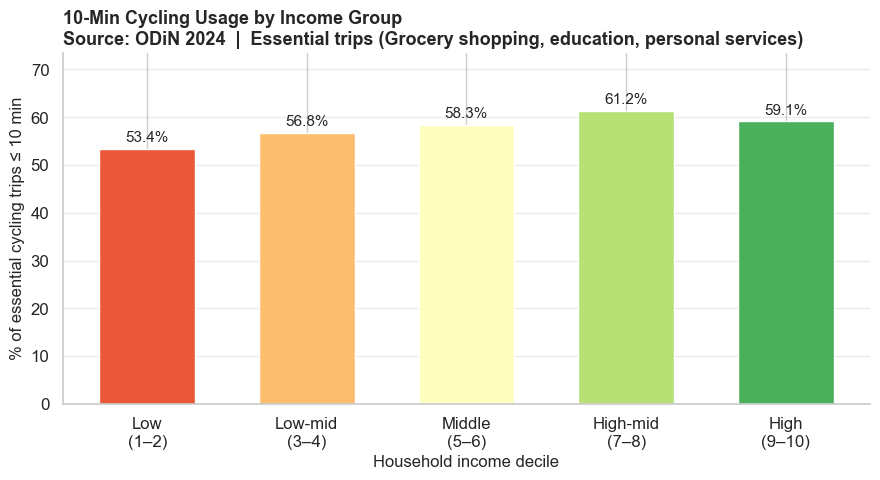

In [38]:
# Figure 3: local cycling on essential trips by income
inc_bike = (
    # Filtering by essential trips, only cycling and oonly known income groups
    df[df['is_essential'] & df['is_bike'] & (df['HHGestInkG'] <= 10)]
    .groupby('income_group', observed=True)
    .apply(lambda g: np.average(g['within10min'], weights=g['wV']) * 100)
    .reset_index(name='pct_bike_local')
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(inc_bike['income_group'].astype(str), inc_bike['pct_bike_local'],
              color=sns.color_palette('RdYlGn', len(inc_bike)), edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_xlabel('Household income decile', fontsize=12)
ax.set_ylabel('% of essential cycling trips ≤ 10 min', fontsize=12)
ax.set_title('10-Min Cycling Usage by Income Group\n'
             'Source: ODiN 2024  |  Essential trips (Grocery shopping, education, personal services)',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylim(0, inc_bike['pct_bike_local'].max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('fig3_bikeusage_income.png', dpi=150)
plt.show()

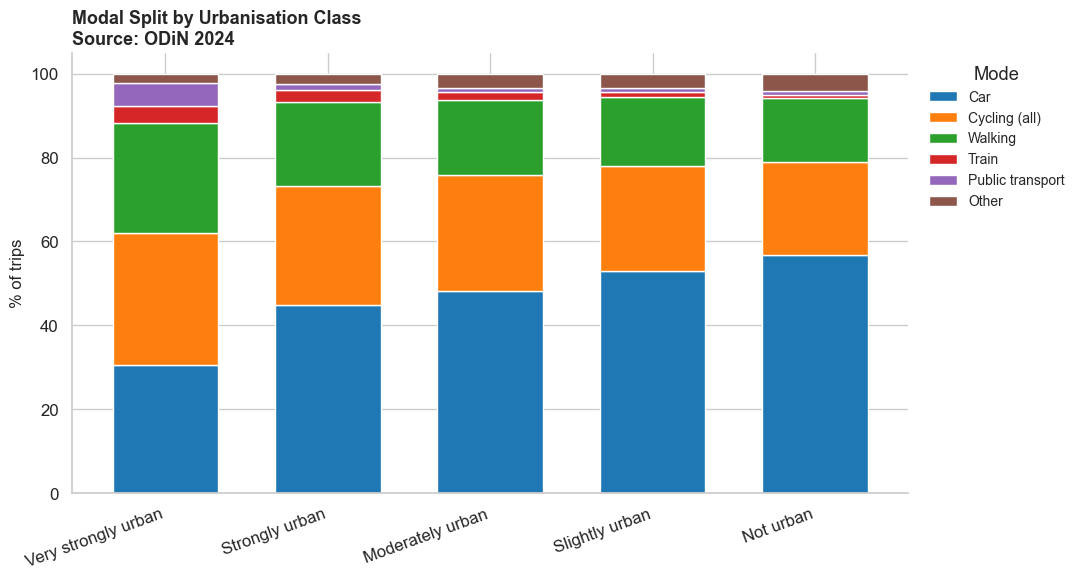

In [39]:
# Figure 4: Modal split by urbanisation
urban_mode = (
    df.groupby(['sted_label', 'mode_simple'], observed=True)
    ['wV'].sum()
    .unstack(fill_value=0)
    # row wise normalize
    .apply(lambda r: r / r.sum() * 100, axis=1)
)

urban_order = ['Very strongly urban', 'Strongly urban', 'Moderately urban',
               'Slightly urban', 'Not urban']
col_order   = ['Car', 'Cycling (all)', 'Walking', 'Train', 'Public transport', 'Other']
urban_mode  = urban_mode.reindex(urban_order)[col_order]

fig, ax = plt.subplots(figsize=(11, 6))
urban_mode.plot(kind='bar', stacked=True, ax=ax,
                color=COLORS[:len(col_order)], edgecolor='white', width=0.65)
ax.set_xlabel('')
ax.set_ylabel('% of trips', fontsize=12)
ax.set_title('Modal Split by Urbanisation Class\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(urban_order, rotation=20, ha='right')
ax.legend(title='Mode', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_modal_urbanisation.png', dpi=150)
plt.show()

C:\Users\daanr\AppData\Local\Temp\ipykernel_10780\312064917.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['within10min'], weights=g['wV']) * 100)


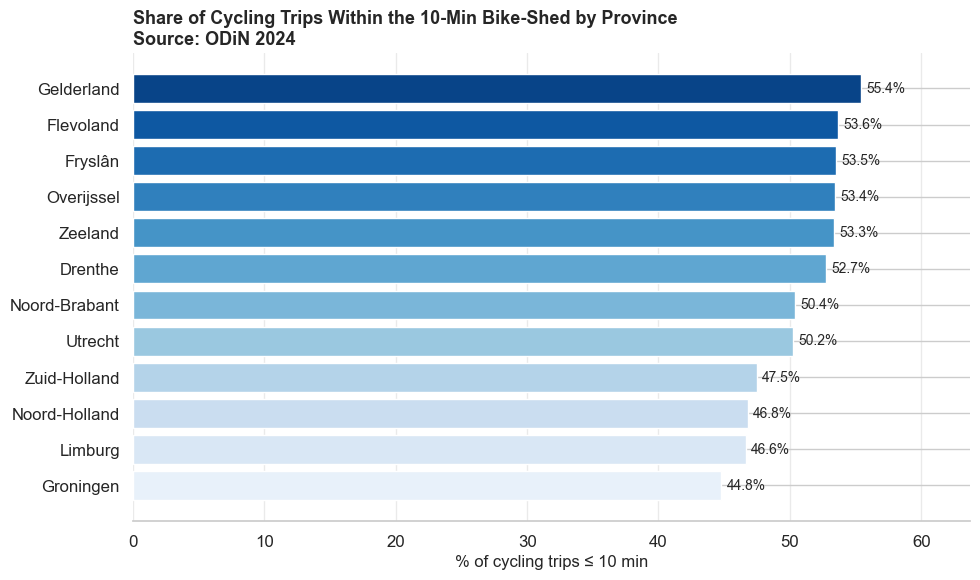

In [40]:
# Figure 5: Local cycling rate by province
prov_local = (
    df[df['is_bike']]
    .groupby('prov_label', observed=True)
    .apply(lambda g: np.average(g['within10min'], weights=g['wV']) * 100)
    .sort_values(ascending=False)
    .reset_index(name='pct_within10min')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prov_local['prov_label'], prov_local['pct_within10min'],
               color=sns.color_palette('Blues_r', len(prov_local)), edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('% of cycling trips ≤ 10 min', fontsize=12)
ax.invert_yaxis()
ax.set_title('Share of Cycling Trips Within the 10-Min Bike-Shed by Province\n'
             'Source: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(0, prov_local['pct_within10min'].max() * 1.15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('fig5_local_biking_province.png', dpi=150)
plt.show()

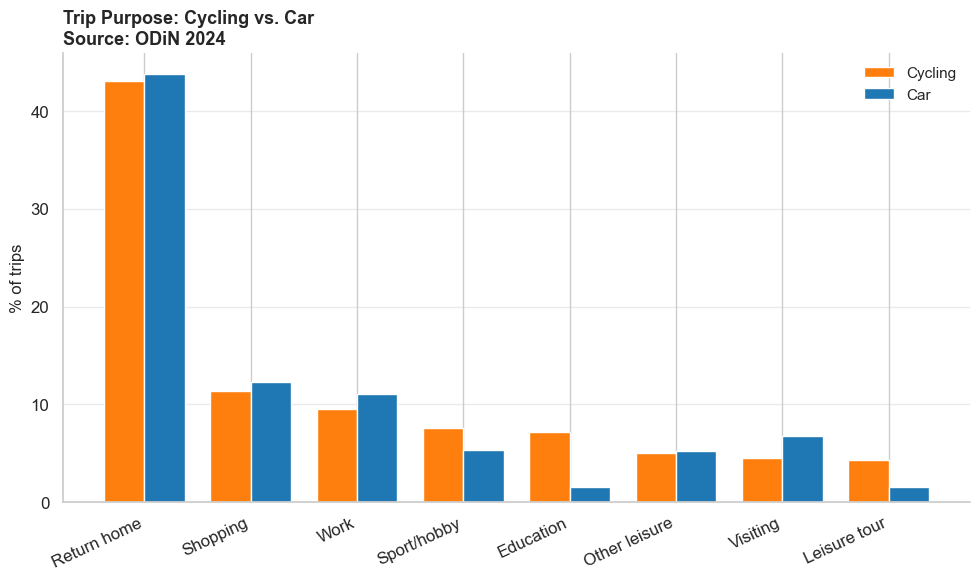

In [41]:
# Figure 6: Trip purpose bike vs car
doel_map = {1:'Return home', 2:'Work', 3:'Business visit', 4:'Professional',
            5:'Pick up/drop off person', 6:'Pick up/drop off goods',
            7:'Education', 8:'Shopping', 9:'Visiting', 10:'Leisure tour',
            11:'Sport/hobby', 12:'Other leisure', 13:'Personal services', 14:'Other'}
df['doel_label'] = df['Doel'].map(doel_map)

bike_purpose = df[df['is_bike']].groupby('doel_label')['wV'].sum()
bike_purpose = bike_purpose / bike_purpose.sum() * 100
car_purpose  = df[df['is_car']].groupby('doel_label')['wV'].sum()
car_purpose  = car_purpose / car_purpose.sum() * 100
# taking 8 biggest purposes
top_purposes = bike_purpose.nlargest(8).index
comp = pd.DataFrame({'Cycling': bike_purpose.reindex(top_purposes).fillna(0),
                     'Car':     car_purpose.reindex(top_purposes).fillna(0)})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top_purposes)); w = 0.38
ax.bar(x - w/2, comp['Cycling'], width=w, label='Cycling', color=COLORS[1], edgecolor='white')
ax.bar(x + w/2, comp['Car'],     width=w, label='Car',     color=COLORS[0], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(top_purposes, rotation=25, ha='right')
ax.set_ylabel('% of trips', fontsize=12)
ax.set_title('Trip Purpose: Cycling vs. Car\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('fig6_purpose_bike_vs_car.png', dpi=150)
plt.show()

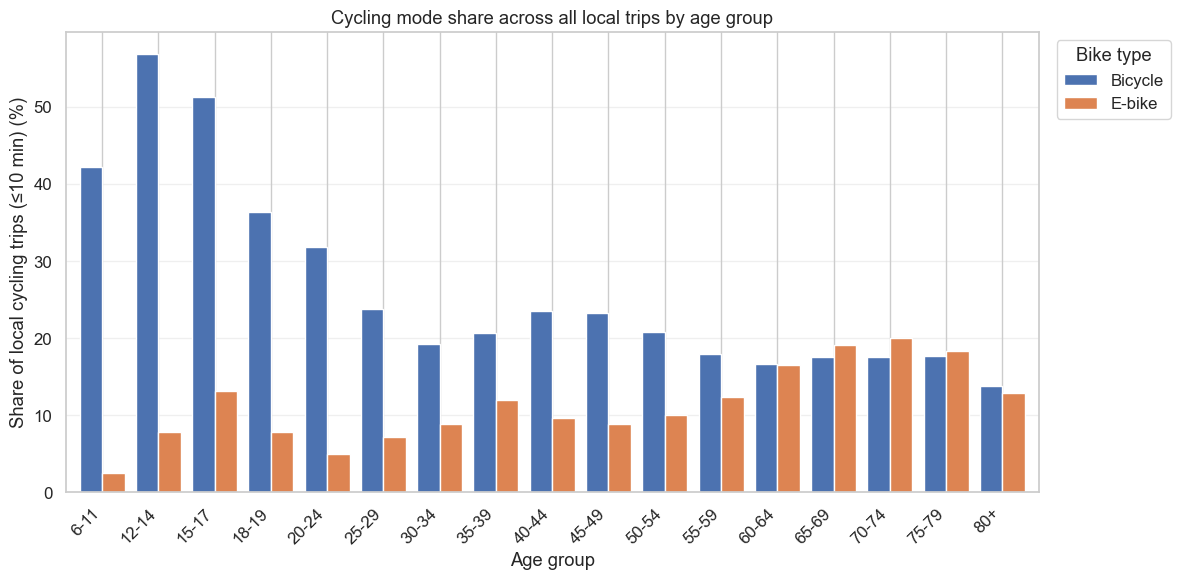

In [42]:
# Figure 7: Bike type x target age

# Labels from codebook
age_labels = {
    2: '6-11', 3: '12-14', 4: '15-17', 5: '18-19',
    6: '20-24', 7: '25-29', 8: '30-34', 9: '35-39',
    10: '40-44', 11: '45-49', 12: '50-54', 13: '55-59',
    14: '60-64', 15: '65-69', 16: '70-74', 17: '75-79',
    18: '80+'
}

bike_labels = {
    6: 'Speed pedelec',
    7: 'E-bike',
    8: 'Bicycle'
}

df['age_group'] = df['KLeeft'].map(age_labels)
df['bike_type'] = df['Hvm'].map(bike_labels)

# all trips within 10 minutes
all_trips = df[df['within10min']].copy()
all_trips['age_group'] = all_trips['KLeeft'].map(age_labels)

# only bike trips within 10 min
bike_age = df[df['within10min'] & df['bike_type'].notna()].copy()

grouped = (
    bike_age
    .groupby(['age_group', 'bike_type'], observed=True)
    ['wV'].sum()
    .reset_index(name='count')
)

total_by_age = (
    all_trips
    .groupby('age_group', observed=True)
    ['wV'].sum()
    .reset_index(name='total')
)

grouped = grouped.merge(total_by_age, on='age_group')
grouped['share_pct'] = grouped['count'] / grouped['total'] * 100

pivot = grouped.pivot(index='age_group', columns='bike_type', values='share_pct').fillna(0)

age_order = list(age_labels.values())
pivot = pivot.reindex(age_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Age group')
ax.set_ylabel('Share of local cycling trips (≤10 min) (%)')
ax.set_title('Cycling mode share across all local trips by age group')
ax.legend(title='Bike type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig7_biketype_agegroup.png', dpi=150)
plt.show()

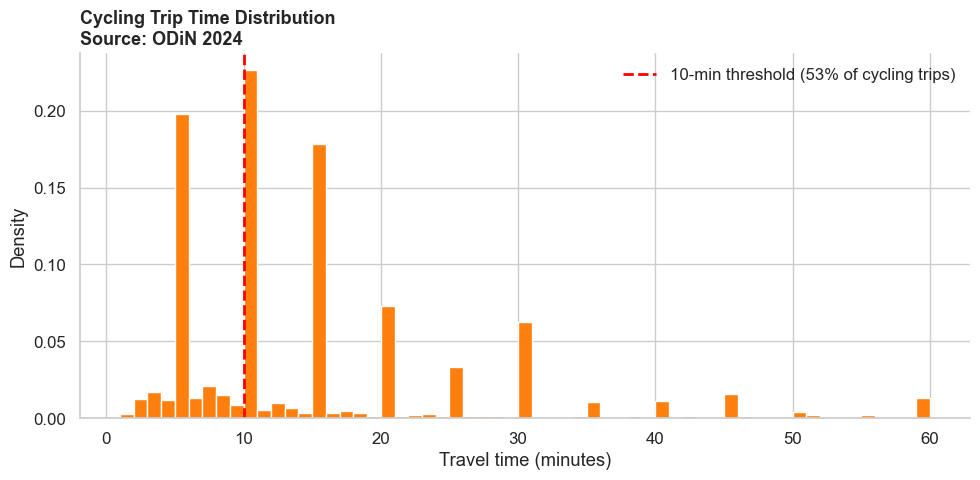

In [43]:
# Figure 8: Cycling trip time distribution
fig, ax = plt.subplots(figsize=(10, 5))
# new dataframe that is cycling and trip time
bt = df[df['is_bike'] & df['Reisduur'].between(1, 60)]
# Percentage of trips within 10 minutes
pct = np.average(bt['within10min'], weights=bt['wV']) * 100
ax.hist(bt['Reisduur'], bins=range(1, 61), weights=bt['wV'],
        color=COLORS[1], edgecolor='white', alpha=1, density=True)
# Vline at 10 min treshold
ax.axvline(10, ls='--', color='red', lw=2,
           label=f'10-min threshold ({pct:.0f}% of cycling trips)')
ax.set_xlabel('Travel time (minutes)')
ax.set_ylabel('Density')
ax.set_title('Cycling Trip Time Distribution\nSource: ODiN 2024', fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig8_time_dist.png', dpi=150)
plt.show()

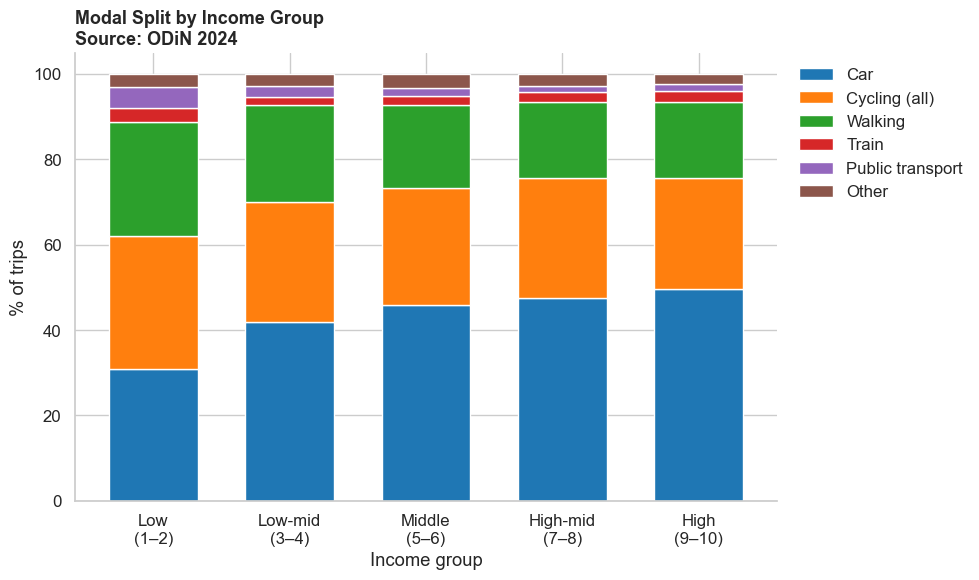

In [44]:
# Figure 9: Modal split by income group
ms_inc = (
    df[df['mode_simple'].notna() & df['HHGestInkG'].between(1, 10)]
    .groupby(['income_group', 'mode_simple'], observed=True)['wV'].sum()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)   # normalise within each income group
)[order]

fig, ax = plt.subplots(figsize=(10, 6))
ms_inc.plot(kind='bar', stacked=True, ax=ax, color=COLORS[:len(order)],
            edgecolor='white', width=0.65)
ax.set_ylabel('% of trips')
ax.set_xlabel('Income group')
ax.set_title('Modal Split by Income Group\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(ms_inc.index, rotation=0)
ax.legend(bbox_to_anchor=(1.01, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig9_modal_income.png', dpi=150)
plt.show()

C:\Users\daanr\AppData\Local\Temp\ipykernel_10780\3668432472.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['within10min'], weights=g['wV']) * 100)


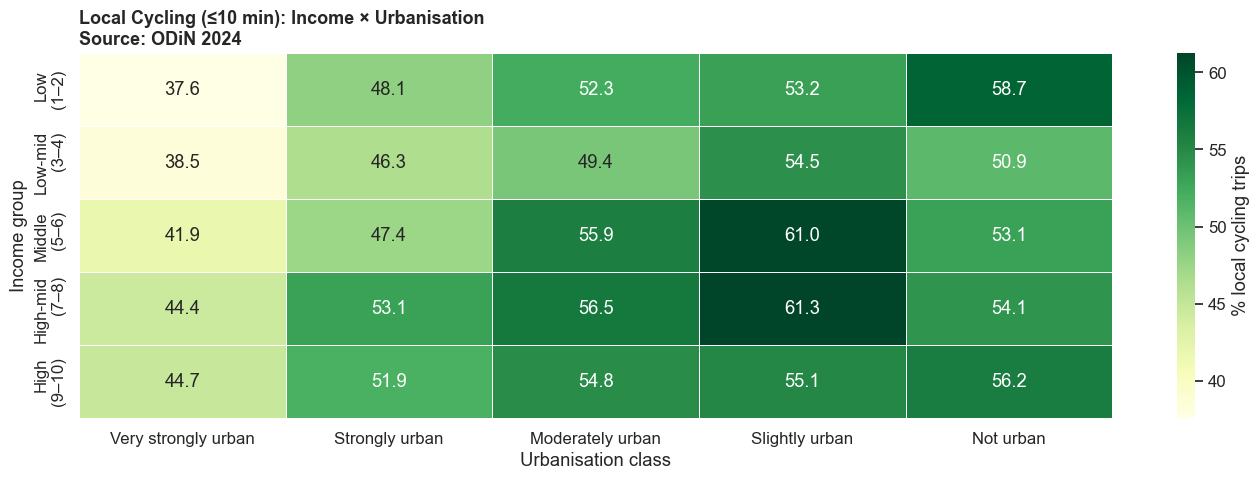

In [45]:
# Figure 10 heatmap of local cycling (within 10 min), income and urbanisation
heat = (df[df['HHGestInkG'].between(1,10) & df['sted_label'].notna() & df['is_bike']]
    .groupby(['income_group','sted_label'], observed=True)
    .apply(lambda g: np.average(g['within10min'], weights=g['wV']) * 100)
    .reset_index(name='pct'))

sted_order = ['Very strongly urban','Strongly urban','Moderately urban','Slightly urban','Not urban']
pivot = heat.pivot(index='income_group', columns='sted_label', values='pct')[sted_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label':'% local cycling trips'})
ax.set_title('Local Cycling (≤10 min): Income × Urbanisation\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Urbanisation class')
ax.set_ylabel('Income group')
plt.tight_layout()
plt.savefig('fig10_heatmap_income_urban.png', dpi=150)
plt.show()

C:\Users\daanr\AppData\Local\Temp\ipykernel_10780\3377369744.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['within10min'], weights=g['wV']) * 100)
C:\Users\daanr\AppData\Local\Temp\ipykernel_10780\3377369744.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(age_order_full, rotation=45, ha='right')


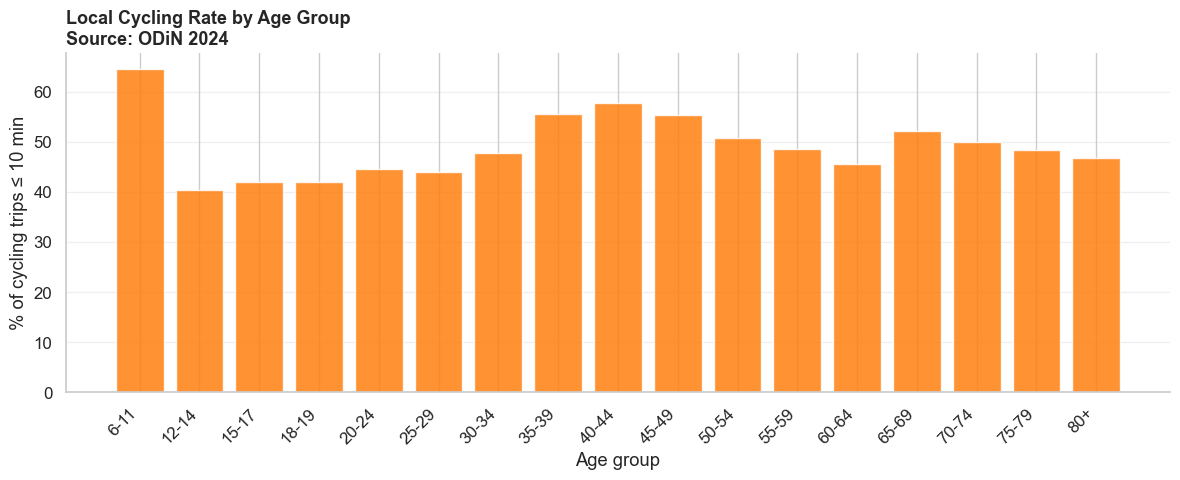

In [46]:
# Figure 11: Local cycling rate by age group
age_order_full = list(age_labels.values())
age_local = (df[df['is_bike'] & df['age_group'].notna()]
    .groupby('age_group', observed=True)
    .apply(lambda g: np.average(g['within10min'], weights=g['wV']) * 100)
    .reindex(age_order_full))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(age_local.index, age_local.values, color=COLORS[1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Age group')
ax.set_ylabel('% of cycling trips ≤ 10 min')
ax.set_title('Local Cycling Rate by Age Group\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(age_order_full, rotation=45, ha='right')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig11_local_cycling_age.png', dpi=150)
plt.show()

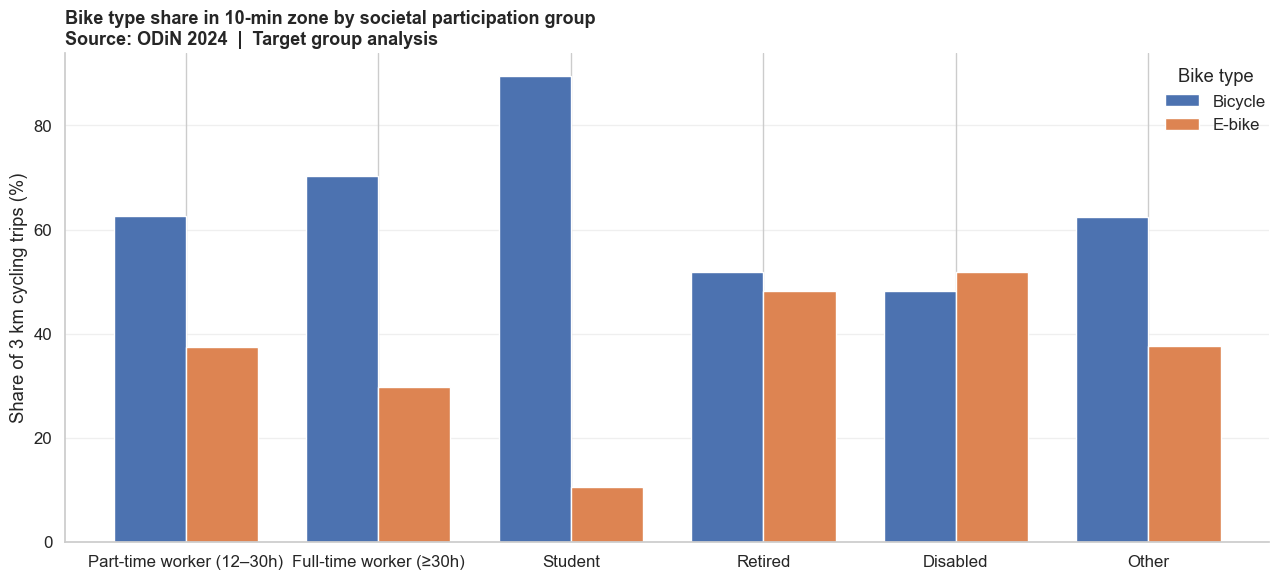

In [47]:
# Figure 12: Bike type x target group
maats_map = {
    1: 'Part-time worker (12–30h)',
    2: 'Full-time worker (≥30h)',
    3: 'Student',
    4: 'Retired',
    5: 'Disabled',
    6: 'Other'
}
maats_order = list(maats_map.values())
df['maats_label'] = df['MaatsPart_DANS24'].map(maats_map) 

# Only grouping local trips and known bike types and target group
bike_maats = df[df['within10min'] & df['bike_type'].notna() & df['maats_label'].notna()].copy()

grouped = (
    bike_maats
    .groupby(['maats_label', 'bike_type'], observed=True)
    ['wV'].sum()
    .reset_index(name='count')
)
totals = bike_maats.groupby('maats_label', observed=True)['wV'].sum().reset_index(name='total')
grouped = grouped.merge(totals, on='maats_label')
grouped['share_pct'] = grouped['count'] / grouped['total'] * 100

pivot = (grouped
    .pivot(index='maats_label', columns='bike_type', values='share_pct')
    .fillna(0)
    .reindex(maats_order)
)

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
ax.set_ylabel('Share of 3 km cycling trips (%)')
ax.set_xlabel('')
ax.set_title('Bike type share in 10-min zone by societal participation group\n'
             'Source: ODiN 2024  |  Target group analysis',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(maats_order, rotation=0, ha='center')
ax.legend(title='Bike type', bbox_to_anchor=(1.01, 1), frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig12_biketype_participation.png', dpi=150)
plt.show()